In [3]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)
print("Working directory:", os.getcwd())

Working directory: c:\Projects\traffic-congestion-prediction


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 3.0.2
Numpy version: 2.2.4


In [5]:
df = pd.read_csv('data/raw/traffic_speed_data.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1855589, 4)

Columns: ['road_id', 'day_id', 'time_id', 'speed']

First 5 rows:


,road_id,day_id,time_id,speed
0,1,1,1,40.893
1,1,1,2,41.938
2,1,1,3,44.098
3,1,1,4,44.483
4,1,1,5,44.172


In [6]:
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Unique Values ===")
print(f"Road segments: {df['road_id'].nunique()}")
print(f"Days: {df['day_id'].nunique()}")
print(f"Time windows: {df['time_id'].nunique()}")

=== Basic Statistics ===
            road_id        day_id       time_id         speed
count  1.855589e+06  1.855589e+06  1.855589e+06  1.855589e+06
mean   1.075490e+02  3.117414e+01  7.250006e+01  3.900740e+01
std    6.197938e+01  1.761503e+01  4.156805e+01  1.082419e+01
min    1.000000e+00  1.000000e+00  1.000000e+00  1.054000e+00
25%    5.400000e+01  1.600000e+01  3.700000e+01  3.240600e+01
50%    1.070000e+02  3.100000e+01  7.200000e+01  3.937400e+01
75%    1.620000e+02  4.600000e+01  1.080000e+02  4.631900e+01
max    2.140000e+02  6.100000e+01  1.440000e+02  1.192700e+02

=== Missing Values ===
road_id    0
day_id     0
time_id    0
speed      0
dtype: int64

=== Unique Values ===
Road segments: 214
Days: 61
Time windows: 144


In [7]:
# How many speeds are suspiciously low?
print("Speeds below 5 km/h:")
print(df[df['speed'] < 5]['speed'].count())

print("\nSpeeds above 100 km/h:")
print(df[df['speed'] > 100]['speed'].count())

print("\nSpeed percentiles:")
percentiles = [1, 5, 10, 90, 95, 99]
for p in percentiles:
    print(f"  {p}th percentile: {df['speed'].quantile(p/100):.2f} km/h")

Speeds below 5 km/h:
865

Speeds above 100 km/h:
17

Speed percentiles:
  1th percentile: 11.23 km/h
  5th percentile: 19.55 km/h
  10th percentile: 24.85 km/h
  90th percentile: 52.68 km/h
  95th percentile: 55.81 km/h
  99th percentile: 63.08 km/h


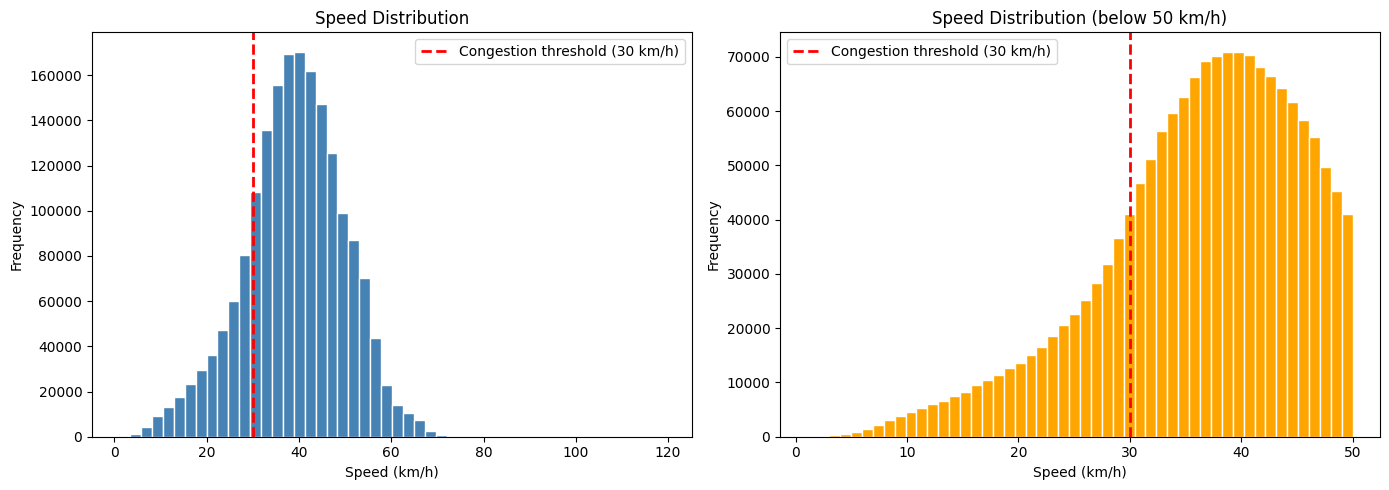

Plot saved to results/figures/


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot - full distribution
axes[0].hist(df['speed'], bins=50, color='steelblue', 
             edgecolor='white')
axes[0].axvline(x=30, color='red', linestyle='--', 
                linewidth=2, label='Congestion threshold (30 km/h)')
axes[0].set_title('Speed Distribution')
axes[0].set_xlabel('Speed (km/h)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right plot - zoom into low speeds
axes[1].hist(df[df['speed'] < 50]['speed'], bins=50, 
             color='orange', edgecolor='white')
axes[1].axvline(x=30, color='red', linestyle='--', 
                linewidth=2, label='Congestion threshold (30 km/h)')
axes[1].set_title('Speed Distribution (below 50 km/h)')
axes[1].set_xlabel('Speed (km/h)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/speed_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/figures/")

In [9]:
# Load the time information table to get real timestamps
time_info = pd.read_csv('data/raw/time_information_table.csv')
print(time_info.head(10))
print(f"\nShape: {time_info.shape}")
print(f"Columns: {time_info.columns.tolist()}")

   time_id start_time end_time
0        1    0:00:00  0:10:00
1        2    0:10:00  0:20:00
2        3    0:20:00  0:30:00
3        4    0:30:00  0:40:00
4        5    0:40:00  0:50:00
5        6    0:50:00  1:00:00
6        7    1:00:00  1:10:00
7        8    1:10:00  1:20:00
8        9    1:20:00  1:30:00
9       10    1:30:00  1:40:00

Shape: (144, 3)
Columns: ['time_id', 'start_time', 'end_time']


In [10]:
day_info = pd.read_csv('data/raw/day_information_table.csv')
print(day_info.head(10))
print(f"\nShape: {day_info.shape}")
print(f"Columns: {day_info.columns.tolist()}")

   day_id       date
0       1   2016/8/1
1       2   2016/8/2
2       3   2016/8/3
3       4   2016/8/4
4       5   2016/8/5
5       6   2016/8/6
6       7   2016/8/7
7       8   2016/8/8
8       9   2016/8/9
9      10  2016/8/10

Shape: (61, 2)
Columns: ['day_id', 'date']


In [11]:
# Merge df with time_info on time_id
df_merged = df.merge(time_info[['time_id', 'start_time']], 
                     on='time_id', how='left')

# Merge result with day_info on day_id
df_merged = df_merged.merge(day_info, 
                             on='day_id', how='left')

print(f"Shape after merge: {df_merged.shape}")
print(f"\nColumns: {df_merged.columns.tolist()}")
print(f"\nFirst 3 rows:")
df_merged.head(3)

Shape after merge: (1855589, 6)

Columns: ['road_id', 'day_id', 'time_id', 'speed', 'start_time', 'date']

First 3 rows:


,road_id,day_id,time_id,speed,start_time,date
0,1,1,1,40.893,0:00:00,2016/8/1
1,1,1,2,41.938,0:10:00,2016/8/1
2,1,1,3,44.098,0:20:00,2016/8/1


In [12]:
# Convert date column to proper datetime format
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Extract hour from start_time
df_merged['hour'] = pd.to_datetime(
    df_merged['start_time'], format='%H:%M:%S').dt.hour

# Extract weekday (0=Monday, 6=Sunday)
df_merged['weekday'] = df_merged['date'].dt.weekday

# Create weekend flag (Saturday=5, Sunday=6)
df_merged['is_weekend'] = (df_merged['weekday'] >= 5).astype(int)

print("New columns added:")
print(df_merged[['start_time', 'date', 'hour', 
                  'weekday', 'is_weekend']].head(10))

print(f"\nWeekday distribution:")
print(df_merged['weekday'].value_counts().sort_index())

print(f"\nWeekend rows: {df_merged['is_weekend'].sum():,}")
print(f"Weekday rows: {(df_merged['is_weekend']==0).sum():,}")

New columns added:
  start_time       date  hour  weekday  is_weekend
0    0:00:00 2016-08-01     0        0           0
1    0:10:00 2016-08-01     0        0           0
2    0:20:00 2016-08-01     0        0           0
3    0:30:00 2016-08-01     0        0           0
4    0:40:00 2016-08-01     0        0           0
5    0:50:00 2016-08-01     0        0           0
6    1:00:00 2016-08-01     1        0           0
7    1:10:00 2016-08-01     1        0           0
8    1:20:00 2016-08-01     1        0           0
9    1:30:00 2016-08-01     1        0           0

Weekday distribution:
weekday
0    273600
1    273570
2    273600
3    274163
4    274080
5    243216
6    243360
Name: count, dtype: int64

Weekend rows: 486,576
Weekday rows: 1,369,013


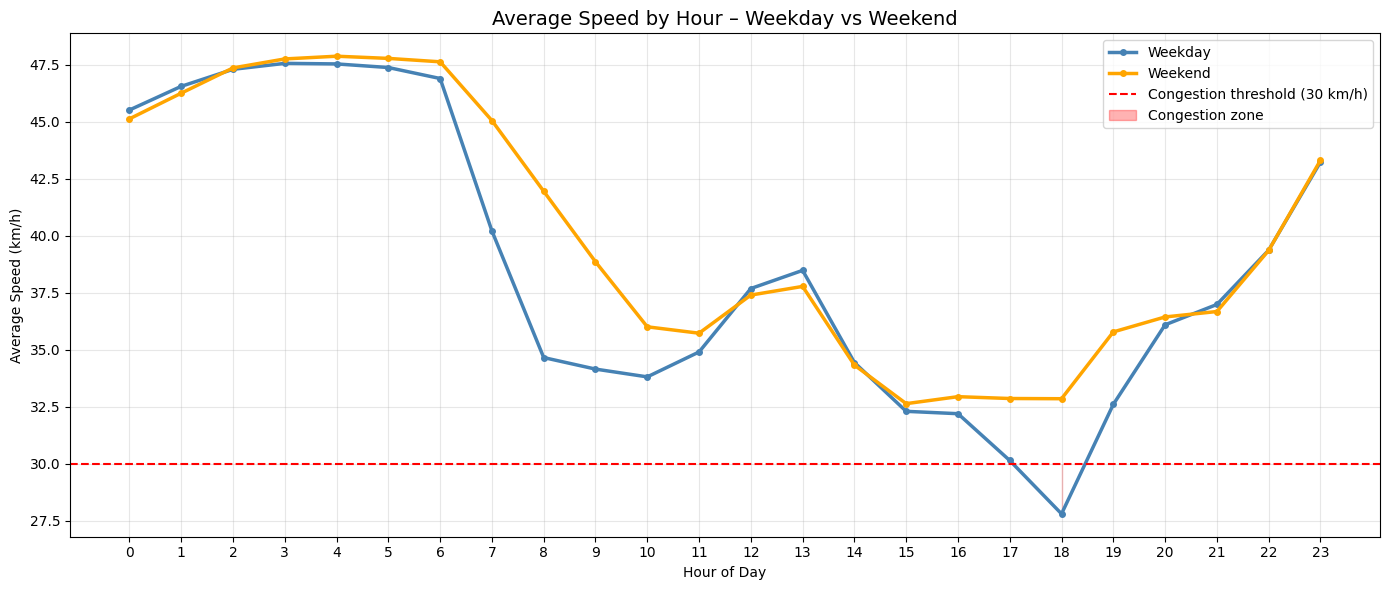

Plot saved!


In [13]:
# Average speed by hour for weekdays vs weekends
hourly_weekday = df_merged[df_merged['is_weekend']==0].groupby(
    'hour')['speed'].mean()
hourly_weekend = df_merged[df_merged['is_weekend']==1].groupby(
    'hour')['speed'].mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hourly_weekday.index, hourly_weekday.values, 
        color='steelblue', linewidth=2.5, 
        marker='o', markersize=4, label='Weekday')
ax.plot(hourly_weekend.index, hourly_weekend.values, 
        color='orange', linewidth=2.5, 
        marker='o', markersize=4, label='Weekend')

ax.axhline(y=30, color='red', linestyle='--', 
           linewidth=1.5, label='Congestion threshold (30 km/h)')
ax.fill_between(hourly_weekday.index, hourly_weekday.values, 
                30, where=(hourly_weekday.values < 30), 
                alpha=0.3, color='red', label='Congestion zone')

ax.set_title('Average Speed by Hour – Weekday vs Weekend', 
             fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Speed (km/h)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/hourly_speed_pattern.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [14]:
# Define congestion threshold
THRESHOLD = 30  # km/h

# Create binary label
df_merged['congestion'] = (df_merged['speed'] < THRESHOLD).astype(int)

# Check distribution
total = len(df_merged)
congestion_count = df_merged['congestion'].sum()
no_congestion_count = total - congestion_count

print(f"=== Congestion Label Distribution ===")
print(f"Total rows:        {total:,}")
print(f"Congestion (1):    {congestion_count:,} "
      f"({congestion_count/total*100:.1f}%)")
print(f"No congestion (0): {no_congestion_count:,} "
      f"({no_congestion_count/total*100:.1f}%)")

=== Congestion Label Distribution ===
Total rows:        1,855,589
Congestion (1):    345,966 (18.6%)
No congestion (0): 1,509,623 (81.4%)


In [15]:
print(f"Rows before cleaning: {len(df_merged):,}")

# Remove speeds above 100 km/h (sensor errors)
df_merged = df_merged[df_merged['speed'] <= 100]

# Remove speeds below 1 km/h (suspicious)
df_merged = df_merged[df_merged['speed'] >= 1]

print(f"Rows after cleaning:  {len(df_merged):,}")
print(f"Rows removed:         "
      f"{1855589 - len(df_merged):,}")

Rows before cleaning: 1,855,589
Rows after cleaning:  1,855,572
Rows removed:         17


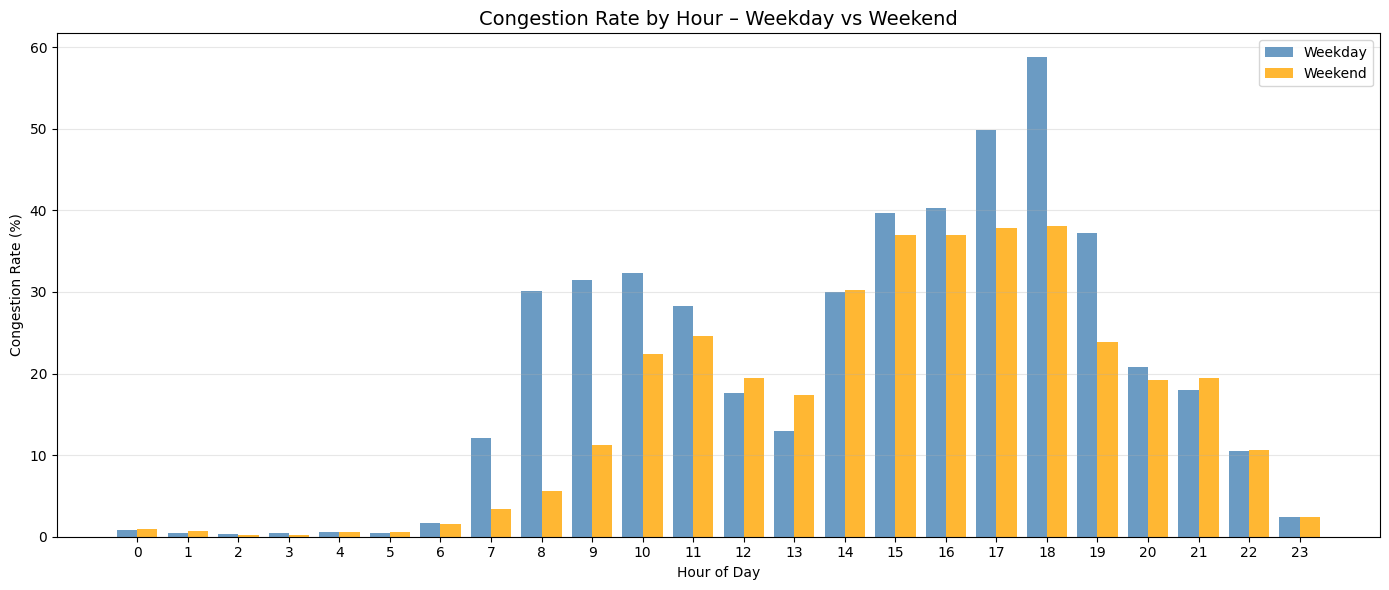

Plot saved!


In [16]:
# Congestion rate per hour for weekday vs weekend
congestion_weekday = df_merged[
    df_merged['is_weekend']==0].groupby('hour')['congestion'].mean() * 100
congestion_weekend = df_merged[
    df_merged['is_weekend']==1].groupby('hour')['congestion'].mean() * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(congestion_weekday.index - 0.2, congestion_weekday.values,
       width=0.4, color='steelblue', label='Weekday', alpha=0.8)
ax.bar(congestion_weekend.index + 0.2, congestion_weekend.values,
       width=0.4, color='orange', label='Weekend', alpha=0.8)

ax.set_title('Congestion Rate by Hour – Weekday vs Weekend',
             fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Congestion Rate (%)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/figures/congestion_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [17]:
# Average congestion rate per road segment
road_congestion = df_merged.groupby('road_id')['congestion'].mean() * 100

print("=== Congestion Rate by Road Segment ===")
print(f"Most congested roads (top 10):")
print(road_congestion.nlargest(10))
print(f"\nLeast congested roads (top 10):")
print(road_congestion.nsmallest(10))
print(f"\nAverage congestion across all roads: "
      f"{road_congestion.mean():.1f}%")
print(f"Std deviation: {road_congestion.std():.1f}%")

=== Congestion Rate by Road Segment ===
Most congested roads (top 10):
road_id
147    71.574074
130    71.573315
114    61.646175
171    54.804189
55     53.287037
141    53.039617
4      51.969490
13     49.453552
69     48.531421
208    47.757286
Name: congestion, dtype: float64

Least congested roads (top 10):
road_id
154    0.204918
187    0.204918
214    0.250455
28     0.295993
19     0.352914
98     0.500911
151    0.580601
198    0.751366
11     0.796903
74     0.979053
Name: congestion, dtype: float64

Average congestion across all roads: 18.9%
Std deviation: 15.2%


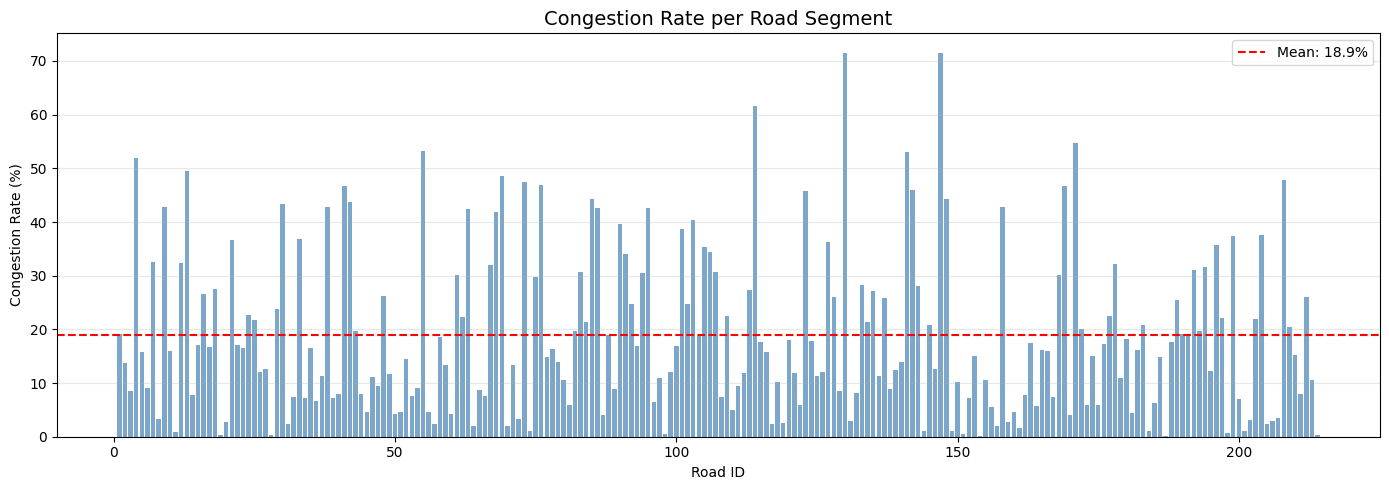

Plot saved!


In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(road_congestion.index, 
       road_congestion.values,
       color='steelblue', alpha=0.7, width=0.8)

ax.axhline(y=road_congestion.mean(), color='red', 
           linestyle='--', linewidth=1.5,
           label=f'Mean: {road_congestion.mean():.1f}%')

ax.set_title('Congestion Rate per Road Segment', fontsize=14)
ax.set_xlabel('Road ID')
ax.set_ylabel('Congestion Rate (%)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/figures/road_congestion_rate.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [19]:
print("=" * 45)
print("       EDA SUMMARY")
print("=" * 45)
print(f"Total observations:      {len(df_merged):,}")
print(f"Road segments:           "
      f"{df_merged['road_id'].nunique()}")
print(f"Days covered:            "
      f"{df_merged['day_id'].nunique()}")
print(f"Date range:              "
      f"{df_merged['date'].min().date()} to "
      f"{df_merged['date'].max().date()}")
print(f"Speed range:             "
      f"{df_merged['speed'].min():.1f} - "
      f"{df_merged['speed'].max():.1f} km/h")
print(f"Mean speed:              "
      f"{df_merged['speed'].mean():.1f} km/h")
print(f"Congestion threshold:    30 km/h")
print(f"Congestion rate:         18.6%")
print(f"Outliers removed:        17 rows")
print(f"Weekend observations:    486,576 (26.2%)")
print(f"Weekday observations:    1,369,013 (73.8%)")
print(f"Peak congestion hour:    18:00 weekday (59%)")
print("=" * 45)

       EDA SUMMARY
Total observations:      1,855,572
Road segments:           214
Days covered:            61
Date range:              2016-08-01 to 2016-09-30
Speed range:             1.1 - 93.8 km/h
Mean speed:              39.0 km/h
Congestion threshold:    30 km/h
Congestion rate:         18.6%
Outliers removed:        17 rows
Weekend observations:    486,576 (26.2%)
Weekday observations:    1,369,013 (73.8%)
Peak congestion hour:    18:00 weekday (59%)


In [20]:
for threshold in [20, 25, 30, 35, 40]:
    pct = (df_merged['speed'] < threshold).mean() * 100
    print(f"Below {threshold} km/h: {pct:.1f}%")

Below 20 km/h: 5.3%
Below 25 km/h: 10.2%
Below 30 km/h: 18.6%
Below 35 km/h: 33.4%
Below 40 km/h: 52.5%
